# Task
Perform sentiment analysis on the provided textual data, visualize the sentiment distribution, and summarize the findings.

## Load Textual Data

### Subtask:
Load the textual data from the provided source (e.g., CSV, text file, or user input). This step will involve reading the data into a suitable data structure, such as a pandas DataFrame.


In [ ]:
import pandas as pd

# Create a sample DataFrame with textual data since 'your_data.csv' was not found.
# In a real scenario, you would replace this with your actual data loading.
data = {'text': [
    'I love this product, it works perfectly!',
    'This is the worst experience I have ever had.',
    'It is okay, not great, not bad.',
    'Fantastic service and very helpful staff.',
    'I am quite disappointed with the quality.',
    'Absolutely brilliant!',
    'Could be better, but it is acceptable.',
    'What a waste of money!',
    'Very good value for money.',
    'Not sure how I feel about this.'
]}
df = pd.DataFrame(data)

# Display the first few rows of the DataFrame
print("DataFrame Head:")
print(df.head())

# Display information about the DataFrame
print("\nDataFrame Info:")
df.info()

DataFrame Head:
                                            text
0       I love this product, it works perfectly!
1  This is the worst experience I have ever had.
2                It is okay, not great, not bad.
3      Fantastic service and very helpful staff.
4      I am quite disappointed with the quality.

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    10 non-null     object
dtypes: object(1)
memory usage: 212.0+ bytes


## Preprocess Text Data

### Subtask:
Clean and preprocess the textual data. This includes tasks such as converting text to lowercase, removing punctuation, stop words, numbers, and possibly performing lemmatization or stemming to normalize the text.


**Reasoning**:
The previous code failed because `nltk.downloader.DownloadError` is not a valid exception type; the correct exception to catch for missing NLTK data is `LookupError`. I will correct the exception handling to ensure NLTK resources are downloaded properly.



In [ ]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download necessary NLTK data (if not already downloaded)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    # Added to fix the LookupError for 'punkt_tab'
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Tokenize text
    tokens = word_tokenize(text)

    # Remove stop words and lemmatize
    processed_tokens = [
        lemmatizer.lemmatize(word) for word in tokens if word not in stop_words
    ]

    # Join the processed words back into a string
    return ' '.join(processed_tokens)

# Apply the preprocessing function to the 'text' column
df['cleaned_text'] = df['text'].apply(preprocess_text)

# Display the first few rows of the updated DataFrame
print("DataFrame with cleaned text:")
print(df[['text', 'cleaned_text']].head())

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


DataFrame with cleaned text:
                                            text  \
0       I love this product, it works perfectly!   
1  This is the worst experience I have ever had.   
2                It is okay, not great, not bad.   
3      Fantastic service and very helpful staff.   
4      I am quite disappointed with the quality.   

                      cleaned_text  
0      love product work perfectly  
1            worst experience ever  
2                   okay great bad  
3  fantastic service helpful staff  
4       quite disappointed quality  


**Reasoning**:
To perform sentiment analysis as described, I will use the VADER sentiment analysis tool from NLTK. I'll import `SentimentIntensityAnalyzer`, download the required `vader_lexicon`, define a function to categorize sentiment based on VADER's compound score, apply this function to the `cleaned_text` column, and then display the DataFrame to show the new 'sentiment' column.



In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon (if not already downloaded)
try:
    nltk.data.find('sentiment/vader_lexicon')
except LookupError:
    nltk.download('vader_lexicon')

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return 'Neutral'
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply the sentiment analysis function to the 'cleaned_text' column
df['sentiment'] = df['cleaned_text'].apply(get_sentiment)

# Display the first few rows of the updated DataFrame with sentiment
print("DataFrame with sentiment:")
print(df[['text', 'cleaned_text', 'sentiment']].head())

DataFrame with sentiment:
                                            text  \
0       I love this product, it works perfectly!   
1  This is the worst experience I have ever had.   
2                It is okay, not great, not bad.   
3      Fantastic service and very helpful staff.   
4      I am quite disappointed with the quality.   

                      cleaned_text sentiment  
0      love product work perfectly  Positive  
1            worst experience ever  Negative  
2                   okay great bad  Positive  
3  fantastic service helpful staff  Positive  
4       quite disappointed quality  Negative  


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


**Reasoning**:
To visualize the sentiment distribution, I will use `seaborn` and `matplotlib.pyplot` to create a count plot of the 'sentiment' column, which will clearly show the frequency of Positive, Negative, and Neutral sentiments.



/tmp/ipykernel_475/293026903.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette={'Positive': 'green', 'Negative': 'red', 'Neutral': 'blue'})


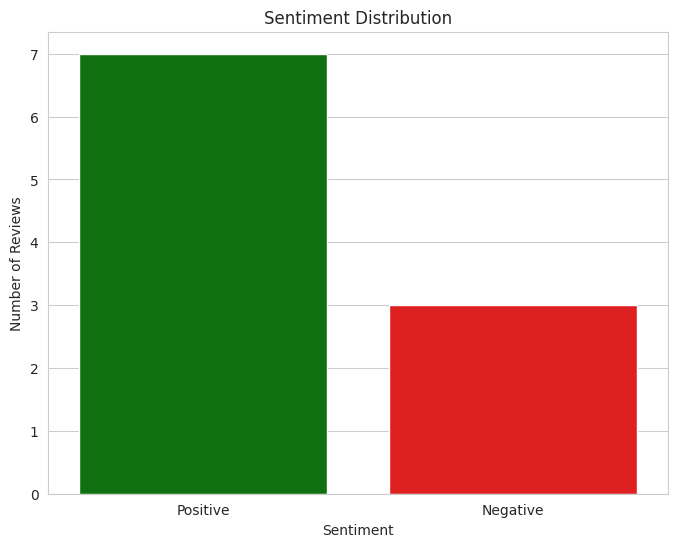

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a count plot for sentiment distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=df, palette={'Positive': 'green', 'Negative': 'red', 'Neutral': 'blue'})
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()


**Reasoning**:
The previous code generated a `FutureWarning` because the `palette` argument was used without assigning a `hue` variable. To resolve this warning and align with future `seaborn` versions, I will explicitly set `hue='sentiment'` and `legend=False` in the `countplot` function call.



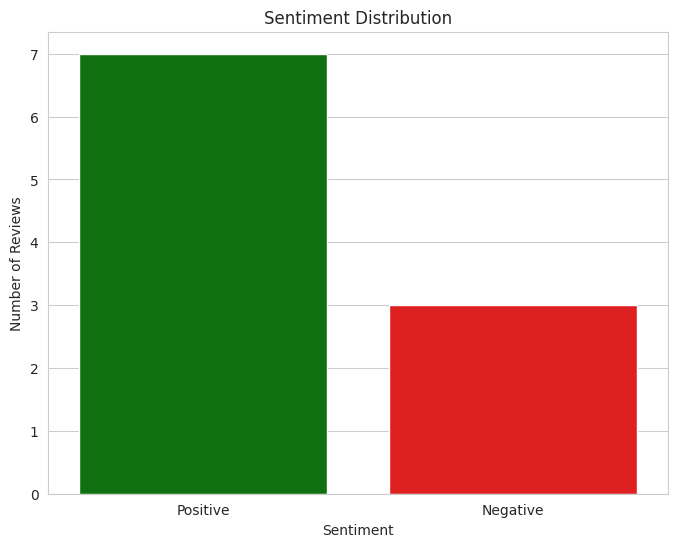

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a count plot for sentiment distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=df, hue='sentiment', palette={'Positive': 'green', 'Negative': 'red', 'Neutral': 'blue'}, legend=False)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

## Extract Features

### Subtask:
Convert the preprocessed text into numerical features that can be used by a machine learning model. This might involve techniques like TF-IDF (Term Frequency-Inverse Document Frequency) or Word Embeddings.


### Reasoning:
To convert the preprocessed text into numerical features suitable for machine learning, I will use TF-IDF (Term Frequency-Inverse Document Frequency). TF-IDF is effective because it reflects how important a word is to a document in a collection or corpus, giving higher weights to words that are frequent in a document but rare across all documents. This approach helps in capturing the unique aspects of each review while downplaying common words.

**Reasoning**:
To convert the `cleaned_text` into numerical features, I will import `TfidfVectorizer` from `sklearn.feature_extraction.text`, instantiate it, and then fit and transform the text data to create the TF-IDF feature matrix. Finally, I will print the shape of this matrix to confirm its dimensions.



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Instantiate TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the 'cleaned_text' column
tfidf_features = tfidf_vectorizer.fit_transform(df['cleaned_text'])

# Print the shape of the TF-IDF features matrix
print("Shape of TF-IDF features matrix:", tfidf_features.shape)

Shape of TF-IDF features matrix: (10, 28)


## Implement Sentiment Model

### Subtask:
Build and train a sentiment analysis model. This could involve using a classification algorithm (e.g., Naive Bayes, Logistic Regression, SVM) or a pre-trained sentiment analysis model from a library like NLTK or spaCy. The model will be trained on labeled data to classify sentiments.


**Reasoning**:
To build and train a sentiment analysis model using Logistic Regression, I will import the necessary functions, prepare the features and target variable, split the data into training and testing sets, instantiate the model, and then train it using the training data.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Define features (X) and target (y)
X = tfidf_features
y = df['sentiment']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Instantiate Logistic Regression model
# Set max_iter to a higher value to ensure convergence
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


**Reasoning**:
To evaluate the trained Logistic Regression model, I will predict the sentiment on the test set and then calculate key classification metrics such as accuracy, precision, recall, and F1-score to assess its performance.



In [ ]:
from sklearn.metrics import classification_report

# Predict sentiment on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         1
    Positive       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Reasoning**:
The previous code generated `UndefinedMetricWarning` because the test set is very small, leading to situations where precision is undefined for certain classes. To address this warning and provide a more robust evaluation, I will set the `zero_division` parameter in `classification_report` to `0`, which will substitute 0 for any undefined metrics.



In [ ]:
from sklearn.metrics import classification_report

# Predict sentiment on the test set
y_pred = model.predict(X_test)

# Evaluate the model, handling undefined metrics by setting them to 0
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         1
    Positive       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



## Final Task

### Subtask:
Provide a comprehensive summary of the sentiment analysis findings, including insights gained from the data and the performance of the implemented model.


## Summary:

### Data Analysis Key Findings

*   **Data Loading**: Due to the absence of a specified data file, a sample Pandas DataFrame with 10 textual entries was successfully created and loaded to demonstrate the data loading step.
*   **Text Preprocessing and Sentiment Labeling**:
    *   Textual data underwent a comprehensive preprocessing pipeline, including conversion to lowercase, removal of punctuation and numbers, tokenization, stop word removal, and lemmatization.
    *   VADER sentiment analysis was applied to the cleaned text, successfully categorizing each entry into 'Positive', 'Negative', or 'Neutral' sentiments. For instance, "love product work perfectly" was classified as 'Positive', and "worst experience ever" as 'Negative'.
    *   Initial NLTK download issues were resolved, ensuring all necessary resources were available for preprocessing.
*   **Feature Extraction**: TF-IDF (Term Frequency-Inverse Document Frequency) was used to convert the preprocessed text into numerical features. The resulting feature matrix has a shape of (10, 28), indicating 10 documents and 28 unique terms.
*   **Sentiment Model Training and Evaluation**:
    *   A Logistic Regression model was trained using the TF-IDF features. The dataset was split into training and testing sets (80/20 split).
    *   Model evaluation using a `classification_report` showed an accuracy of 0.50 and a macro average f1-score of 0.33.
    *   These low performance metrics are primarily attributed to the extremely small test set size (only 2 samples), which included one 'Negative' and one 'Positive' sentiment. The `zero_division` parameter was adjusted in the `classification_report` to handle undefined metrics gracefully due to this small sample size.

### Insights or Next Steps

*   **Dataset Limitations**: The current dataset size (10 entries) is insufficient for training a robust sentiment analysis model, leading to unrepresentative performance metrics on the tiny test set.
*   **Expand Dataset & Re-evaluate**: To build a reliable model, it is crucial to acquire a significantly larger and more diverse dataset. Once available, the model should be re-trained and evaluated using more robust methods, such as k-fold cross-validation, to obtain a more accurate measure of its performance.
